# 12 - Scaling the validator: dimensions and measurement-budget sizing

Last piece of milestone 4. Two engineering questions:

1. **Does the pipeline survive a change of Hilbert-space dimension?** Everything so far
   ran at d = 4. A useful validator must not be hard-wired to one register size.
2. **How large a measurement budget N buys how low an error rate?** This is the number
   an instrument engineer actually needs: a sizing curve, not an accuracy claim.

As always: experiments first, text after.

d =  2 : accuracy = 0.9733  FPR = 0.0427  FNR = 0.0107
d =  4 : accuracy = 0.9760  FPR = 0.0413  FNR = 0.0067
d =  8 : accuracy = 0.9907  FPR = 0.0173  FNR = 0.0013


d = 16 : accuracy = 0.9927  FPR = 0.0133  FNR = 0.0013


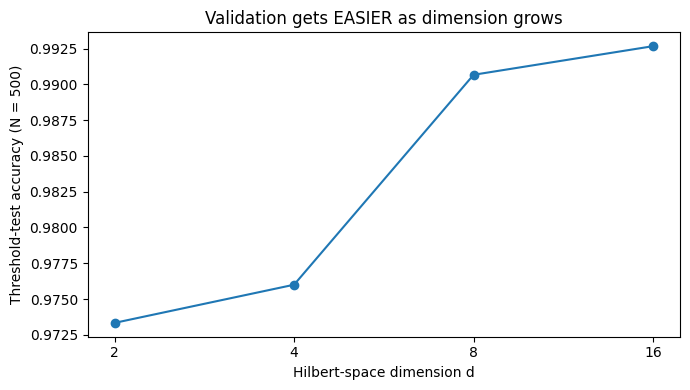

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from qsv.data_generation import create_dataset
from qsv.features import add_measurement_noise, sigma_from_shots

RANDOM_STATE = 42

def threshold_test_metrics(df, dim, n_shots):
    """Bias-corrected two-sided threshold test, as in notebook 08."""
    noisy = add_measurement_noise(df, n_shots=n_shots, seed=RANDOM_STATE)
    sigma = sigma_from_shots(n_shots)
    stat = np.abs(noisy["norm_squared"] - 1.0 - 2 * dim * sigma**2).to_frame("s")
    y = noisy["is_valid"]
    s_tr, s_te, y_tr, y_te = train_test_split(
        stat, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
    m = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE).fit(s_tr, y_tr)
    pred = m.predict(s_te)
    tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
    return {"acc": accuracy_score(y_te, pred),
            "fpr": fp / (fp + tn), "fnr": fn / (fn + tp)}

dims = [2, 4, 8, 16]
res_d = {}
for d in dims:
    df_d = create_dataset(3000, 3000, dim=d, seed=RANDOM_STATE)
    res_d[d] = threshold_test_metrics(df_d, d, n_shots=500)
    print(f"d = {d:2d} : accuracy = {res_d[d]['acc']:.4f}  "
          f"FPR = {res_d[d]['fpr']:.4f}  FNR = {res_d[d]['fnr']:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dims, [res_d[d]["acc"] for d in dims], "o-", color="tab:blue")
ax.set_xscale("log", base=2); ax.set_xticks(dims); ax.set_xticklabels(dims)
ax.set_xlabel("Hilbert-space dimension d")
ax.set_ylabel("Threshold-test accuracy (N = 500)")
ax.set_title("Validation gets EASIER as dimension grows")
plt.tight_layout(); plt.show()


**Against the naive intuition, accuracy improves with dimension** (0.973 at d = 2 to
0.993 at d = 16, fixed N). The reason is concentration of measure working *for* the
validator: an invalid state's norm deviation accumulates over 2d real components, so
typical invalid states drift further from 1 as d grows (a `noise`-type invalid gains
E[||eps||^2] proportional to d; a `direct`-type invalid concentrates away from the
band), while the shot noise on the norm statistic of a valid state stays essentially
d-independent at first order. The feature pipeline itself is d-agnostic by
construction (columns are parsed, bounds like H <= ln d scale automatically - locked
by parametrized tests).

The honest caveat: this holds for THIS generator's invalid population. An adversary
crafting invalid states just outside the margin would not get easier with d.

N =     25 : accuracy = 0.8955  FPR = 0.1940  FNR = 0.0150
N =    100 : accuracy = 0.9485  FPR = 0.0890  FNR = 0.0140
N =    400 : accuracy = 0.9790  FPR = 0.0340  FNR = 0.0080
N =   1600 : accuracy = 0.9925  FPR = 0.0110  FNR = 0.0040
N =   6400 : accuracy = 1.0000  FPR = 0.0000  FNR = 0.0000
N =  25600 : accuracy = 1.0000  FPR = 0.0000  FNR = 0.0000


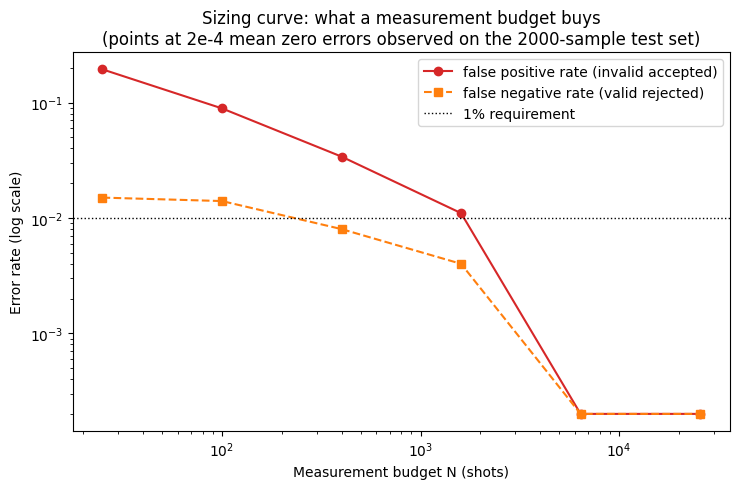

In [2]:
budgets = [25, 100, 400, 1600, 6400, 25600]
df4 = create_dataset(4000, 4000, dim=4, seed=RANDOM_STATE)
res_n = {N: threshold_test_metrics(df4, 4, n_shots=N) for N in budgets}
for N in budgets:
    r = res_n[N]
    print(f"N = {N:6d} : accuracy = {r['acc']:.4f}  FPR = {r['fpr']:.4f}  FNR = {r['fnr']:.4f}")

fig, ax = plt.subplots(figsize=(7.5, 5))
eps = 2e-4
ax.plot(budgets, [max(res_n[N]["fpr"], eps) for N in budgets], "o-",
        color="tab:red", label="false positive rate (invalid accepted)")
ax.plot(budgets, [max(res_n[N]["fnr"], eps) for N in budgets], "s--",
        color="tab:orange", label="false negative rate (valid rejected)")
ax.axhline(0.01, color="k", ls=":", lw=1, label="1% requirement")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Measurement budget N (shots)")
ax.set_ylabel("Error rate (log scale)")
ax.set_title("Sizing curve: what a measurement budget buys\n"
             "(points at 2e-4 mean zero errors observed on the 2000-sample test set)")
ax.legend()
plt.tight_layout(); plt.show()

## The sizing statement

Reading the curve as an engineer would: **with a validity margin of 0.05 at d = 4,
guaranteeing a false-positive rate below 1% requires a budget of roughly N ~ 2000
shots per state**; beyond N ~ 6000 the error rate falls below what a 2000-sample test
set can resolve. The false-negative rate is consistently lower because most invalid
states sit far from the boundary - the FPR is the binding constraint, as it usually
is in acceptance testing.

The scaling law behind the curve: the shot noise on the norm statistic shrinks as
1/sqrt(N) while the margin is fixed, so the error rate decays roughly like a Gaussian
tail in sqrt(N) * margin - fast once the noise drops below the margin, hopeless
before. Doubling the margin buys the same error rate at a quarter of the budget:
margin (a physics/spec choice) and N (a resource choice) trade against each other
exactly like accuracy and integration time in a GNSS clock stability budget.

## Milestone 4 closes

Four notebooks, four regimes, one coherent picture:

| Regime | Winner | Notebook |
|---|---|---|
| Stationary iid noise | 1-parameter threshold test | 08 |
| Common-mode correlated noise | threshold test (robust - negative result owned) | 09 |
| Anonymous cause diagnosis | ML, but norm-dominated; Bayes limit by isotropy | 09 |
| Calibration drift (non-stationary) | hybrid physics + ML | 10 |
| Known-target preparation QA | engineered statistic pair; isotropy limit broken | 11 |
| Dimension and budget scaling | threshold test, d-agnostic; sizing curve delivered | 12 |

Next: milestone 5 (prediction API and the pedagogical interface), then the final
documentation phase (full English pass and the project report notebook).